In [1]:
import os, random, gc, itertools, json
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report

In [2]:
CLASS_NAMES   = ['0', '1', '2', '3', '4']
DISPLAY_NAMES = [
    'Grade 0 (Healthy)',
    'Grade 1 (Doubtful)',
    'Grade 2 (Minimal)',
    'Grade 3 (Moderate)',
    'Grade 4 (Severe)',
]
NUM_CLASSES   = len(CLASS_NAMES)

DATASET_DIR   = '/kaggle/input/datasets/tommyngx/kneeoa'
TRAIN_DIR     = f'{DATASET_DIR}/train'
VAL_DIR       = f'{DATASET_DIR}/val'
TEST_DIR      = f'{DATASET_DIR}/test'
AUTO_TEST_DIR = f'{DATASET_DIR}/auto_test'

CKPT_DIR      = '/kaggle/working'
os.makedirs(CKPT_DIR, exist_ok=True)

device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS    = 100
SEARCH_SEED   = 33
SEARCH_EPOCHS = 40

In [3]:
ARCH_SEARCH = {
    'lr'          : [1e-3, 5e-4, 1e-4, 5e-5],
    'weight_decay': [1e-4, 1e-5, 1e-6],
    'batch_size'  : [16, 32, 64],
    'dropout'     : [0.2, 0.3, 0.4, 0.5],
}
DISTILL_SEARCH = {
    'temperature': [3, 5, 7, 10],
    'alpha'      : [0.3, 0.5, 0.7, 0.9],
}
BETA_SEARCH = [0.5, 1.0, 2.0]

In [4]:
def save_phase_results(phase_name, results):
    path = f'{CKPT_DIR}/phase_{phase_name}.json'
    with open(path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"  [checkpoint] Phase '{phase_name}' results saved → {path}")

def load_phase_results(phase_name):
    path = f'{CKPT_DIR}/phase_{phase_name}.json'
    if os.path.exists(path):
        with open(path, 'r') as f:
            results = json.load(f)
        print(f"  [checkpoint] Phase '{phase_name}' already done — loaded from {path}")
        return results
    return None

def phase_is_done(phase_name):
    return os.path.exists(f'{CKPT_DIR}/phase_{phase_name}.json')

def save_best_weights(path, epoch, model, qwk):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'qwk': qwk}, path)

def save_resume_ckpt(path, epoch, model, optimizer, scheduler, scaler,
                     history, best_qwk, best_preds, best_labels):
    torch.save({'epoch':            epoch,
                'model_state_dict': model.state_dict(),
                'optimizer':        optimizer.state_dict(),
                'scheduler':        scheduler.state_dict(),
                'scaler':           scaler.state_dict(),
                'history':          history,
                'best_qwk':         best_qwk,
                'best_preds':       best_preds,
                'best_labels':      best_labels}, path)

def load_resume_ckpt(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    scaler.load_state_dict(ckpt['scaler'])
    print(f"  [checkpoint] Resumed from epoch {ckpt['epoch']+1} "
          f"(best QWK so far: {ckpt['best_qwk']:.4f})")
    return (ckpt['epoch'] + 1, ckpt['history'],
            ckpt['best_qwk'], ckpt['best_preds'], ckpt['best_labels'])

In [5]:
def set_seed(seed=30):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def _compute_mse_rmse(labels, preds):
    la = np.array(labels, dtype=np.float32)
    pa = np.array(preds,  dtype=np.float32)
    mse = float(np.mean((la - pa) ** 2))
    return mse, float(np.sqrt(mse)), float(np.mean(np.abs(la - pa)))

In [6]:
def build_df_from_folder(root_dir: str, class_names: list) -> pd.DataFrame:
    """Scan class subfolders and return a DataFrame with (filepath, diagnosis)."""
    records = []
    for label, cls in enumerate(class_names):
        cls_dir = Path(root_dir) / cls
        if not cls_dir.exists():
            print(f"  WARNING: folder not found → {cls_dir}")
            continue
        found = 0
        for img_path in cls_dir.glob('*'):
            if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                records.append({'filepath': str(img_path), 'diagnosis': label})
                found += 1
        print(f"  [{label}] {DISPLAY_NAMES[label]:<26s}: {found} images")
    df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
    return df

print("\n── Building train split ─────────────────────────────────────────────────")
train_df = build_df_from_folder(TRAIN_DIR, CLASS_NAMES)

print("\n── Building val split (provided) ────────────────────────────────────────")
val_df = build_df_from_folder(VAL_DIR, CLASS_NAMES)

print("\n── Building test split ──────────────────────────────────────────────────")
test_df = build_df_from_folder(TEST_DIR, CLASS_NAMES)

print("\n── Building auto_test split ─────────────────────────────────────────────")
auto_test_df = build_df_from_folder(AUTO_TEST_DIR, CLASS_NAMES)

train_df     = train_df.reset_index(drop=True)
val_df       = val_df.reset_index(drop=True)
test_df      = test_df.reset_index(drop=True)
auto_test_df = auto_test_df.reset_index(drop=True)

print(f"\n  Train: {len(train_df)} | Val: {len(val_df)} | "
      f"Test: {len(test_df)} | Auto-Test: {len(auto_test_df)}")


── Building train split ─────────────────────────────────────────────────
  [0] Grade 0 (Healthy)         : 2286 images
  [1] Grade 1 (Doubtful)        : 1046 images
  [2] Grade 2 (Minimal)         : 1516 images
  [3] Grade 3 (Moderate)        : 757 images
  [4] Grade 4 (Severe)          : 173 images

── Building val split (provided) ────────────────────────────────────────
  [0] Grade 0 (Healthy)         : 328 images
  [1] Grade 1 (Doubtful)        : 153 images
  [2] Grade 2 (Minimal)         : 212 images
  [3] Grade 3 (Moderate)        : 106 images
  [4] Grade 4 (Severe)          : 27 images

── Building test split ──────────────────────────────────────────────────
  [0] Grade 0 (Healthy)         : 639 images
  [1] Grade 1 (Doubtful)        : 296 images
  [2] Grade 2 (Minimal)         : 447 images
  [3] Grade 3 (Moderate)        : 223 images
  [4] Grade 4 (Severe)          : 51 images

── Building auto_test split ─────────────────────────────────────────────
  [0] Grade 0 (Healthy) 

In [7]:
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

In [8]:
class OasisDataset(Dataset):
    """Filepath-based dataset; works for any folder structure sharing the same schema."""
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['diagnosis']), dtype=torch.long)

In [9]:
class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[x]).values

val_loader       = DataLoader(OasisDataset(val_df,       val_tfm),
                               batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader      = DataLoader(OasisDataset(test_df,      val_tfm),
                               batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
auto_test_loader = DataLoader(OasisDataset(auto_test_df, val_tfm),   # NEW
                               batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

def make_train_loader(batch_size):
    return DataLoader(
        OasisDataset(train_df, train_tfm),
        batch_size = batch_size,
        sampler    = WeightedRandomSampler(
            torch.tensor(sample_weights, dtype=torch.float),
            len(sample_weights), replacement=True),
        num_workers=4, pin_memory=True)

In [10]:
class CoralHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc   = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))   # 4 thresholds

    def forward(self, x):
        return self.fc(x) + self.bias

def coral_loss(logits, labels, num_classes=NUM_CLASSES):
    targets = torch.zeros(labels.size(0), num_classes - 1, device=labels.device)
    for k in range(num_classes - 1):
        targets[:, k] = (labels > k).float()
    return F.binary_cross_entropy_with_logits(logits, targets)

def coral_predict(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1).long()

def coral_to_softmax(logits):
    cum   = torch.sigmoid(logits)
    p0    = 1.0 - cum[:, 0:1]
    pmid  = cum[:, :-1] - cum[:, 1:]
    plast = cum[:, -1:]
    return torch.cat([p0, pmid, plast], dim=1).clamp(min=1e-6)   # 5 elements

def coral_kd_loss(s_logits, t_logits, labels, alpha, temperature, beta):
    ord_loss     = coral_loss(s_logits, labels)
    s_probs      = coral_to_softmax(s_logits)
    t_soft       = F.softmax(t_logits / temperature, dim=1)
    s_soft       = s_probs ** (1.0 / temperature)
    s_soft       = s_soft / s_soft.sum(dim=1, keepdim=True)
    s_log_t      = torch.log(s_soft + 1e-8)
    kd_loss      = F.kl_div(s_log_t, t_soft, reduction='batchmean') * (temperature ** 2)
    return (1 - alpha) * beta * ord_loss + alpha * kd_loss

In [11]:
def make_mobilenet_ce(dropout):
    m       = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_feat = m.classifier[-1].in_features
    m.classifier[-1] = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_feat, NUM_CLASSES))
    return m

def make_mobilenet_coral(dropout):
    m       = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_feat = m.classifier[-1].in_features
    m.classifier[-1] = nn.Dropout(p=dropout)
    m.coral_head     = CoralHead(in_feat, NUM_CLASSES)
    return m

def get_resnet50_teacher():
    m    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)   # 5-way output
    return m

In [12]:
# LR × WD
def train_ce_only_arch_search(lr, weight_decay, batch_size, dropout,
                               num_epochs=SEARCH_EPOCHS):
    loader = make_train_loader(batch_size)
    set_seed(SEARCH_SEED)
    model  = make_mobilenet_ce(dropout).to(device)
    opt    = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    scaler = torch.amp.GradScaler('cuda')
    best_qwk = -1.0
    for epoch in range(num_epochs):
        model.train()
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                loss = F.cross_entropy(model(imgs), labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        model.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        if qwk > best_qwk: best_qwk = qwk
    del model; cleanup_memory()
    return best_qwk

# LR × WD
stage0a_results = load_phase_results('stage0a')
if stage0a_results is None:
    print("\n" + "="*65)
    print("  STAGE 0A — LR × Weight Decay  (BS=32, Dropout=0.3 fixed)")
    print("="*65)

    partial_path_0a = f'{CKPT_DIR}/phase_stage0a_partial.json'
    stage0a_results = []
    if os.path.exists(partial_path_0a):
        with open(partial_path_0a, 'r') as f:
            stage0a_results = json.load(f)
        print(f"  [checkpoint] Partial progress loaded: {len(stage0a_results)} trials done")

    completed_keys_0a = {(r['lr'], r['wd']) for r in stage0a_results}

    for lr, wd in itertools.product(ARCH_SEARCH['lr'], ARCH_SEARCH['weight_decay']):
        if (lr, wd) in completed_keys_0a:
            print(f"  [skip] LR={lr}  WD={wd}  (already done)")
            continue
        print(f"  Trial | LR={lr}  WD={wd}", end='  ', flush=True)
        qwk = train_ce_only_arch_search(lr=lr, weight_decay=wd, batch_size=32, dropout=0.3)
        print(f"→ QWK={qwk:.4f}")
        stage0a_results.append({'lr': lr, 'wd': wd, 'qwk': qwk})
        with open(partial_path_0a, 'w') as f:
            json.dump(stage0a_results, f, indent=2)

    stage0a_results.sort(key=lambda x: x['qwk'], reverse=True)
    save_phase_results('stage0a', stage0a_results)
    if os.path.exists(partial_path_0a):
        os.remove(partial_path_0a)

best_lr = stage0a_results[0]['lr']
best_wd = stage0a_results[0]['wd']
print(f"\n  Stage 0A best: LR={best_lr}  WD={best_wd}  QWK={stage0a_results[0]['qwk']:.4f}")

# BS × Dropout
stage0b_results = load_phase_results('stage0b')
if stage0b_results is None:
    print("\n" + "="*65)
    print(f"  STAGE 0B — Batch Size × Dropout  (LR={best_lr}, WD={best_wd} fixed)")
    print("="*65)

    partial_path_0b = f'{CKPT_DIR}/phase_stage0b_partial.json'
    stage0b_results = []
    if os.path.exists(partial_path_0b):
        with open(partial_path_0b, 'r') as f:
            stage0b_results = json.load(f)
        print(f"  [checkpoint] Partial progress loaded: {len(stage0b_results)} trials done")

    completed_keys_0b = {(r['bs'], r['dropout']) for r in stage0b_results}

    for bs, dr in itertools.product(ARCH_SEARCH['batch_size'], ARCH_SEARCH['dropout']):
        if (bs, dr) in completed_keys_0b:
            print(f"  [skip] BS={bs}  Dropout={dr}  (already done)")
            continue
        print(f"  Trial | BS={bs}  Dropout={dr}", end='  ', flush=True)
        qwk = train_ce_only_arch_search(lr=best_lr, weight_decay=best_wd,
                                        batch_size=bs, dropout=dr)
        print(f"→ QWK={qwk:.4f}")
        stage0b_results.append({'bs': bs, 'dropout': dr, 'qwk': qwk})
        with open(partial_path_0b, 'w') as f:
            json.dump(stage0b_results, f, indent=2)

    stage0b_results.sort(key=lambda x: x['qwk'], reverse=True)
    save_phase_results('stage0b', stage0b_results)
    if os.path.exists(partial_path_0b):
        os.remove(partial_path_0b)

best_bs      = stage0b_results[0]['bs']
best_dropout = stage0b_results[0]['dropout']
print(f"\n  Stage 0B best: BS={best_bs}  Dropout={best_dropout}  "
      f"QWK={stage0b_results[0]['qwk']:.4f}")
print("\n" + "="*65)
print("  STAGE 0 COMPLETE — Shared Architecture Config")
print("="*65)
print(f"  LR={best_lr}  WD={best_wd}  BS={best_bs}  Dropout={best_dropout}")

train_loader = make_train_loader(best_bs)

  [checkpoint] Phase 'stage0a' already done — loaded from /kaggle/working/phase_stage0a.json

  Stage 0A best: LR=0.001  WD=0.0001  QWK=0.7921
  [checkpoint] Phase 'stage0b' already done — loaded from /kaggle/working/phase_stage0b.json

  Stage 0B best: BS=64  Dropout=0.3  QWK=0.8035

  STAGE 0 COMPLETE — Shared Architecture Config
  LR=0.001  WD=0.0001  BS=64  Dropout=0.3


In [13]:
def train_teacher_ce(model, name, save_path):
    resume_path = save_path.replace('.pth', '_resume.pth')
    model       = model.to(device)
    opt         = optim.AdamW(model.parameters(), lr=best_lr, weight_decay=best_wd)
    sched       = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler      = torch.amp.GradScaler('cuda')
    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                   'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0; best_preds, best_labels = [], []; start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, model, opt, sched, scaler)

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); epoch_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                loss = F.cross_entropy(model(imgs), labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            epoch_loss += loss.item()
        sched.step()
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        model.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        acc = np.mean(np.array(v_labels) == np.array(v_preds))
        _, rmse, mae = _compute_mse_rmse(v_labels, v_preds)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)
        print(f"  [{name}] Epoch {epoch+1:03d} | Loss={avg_loss:.4f} | "
              f"Acc={acc*100:.2f}% | QWK={qwk:.4f}")
        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(save_path, epoch+1, model, best_qwk)
        save_resume_ckpt(resume_path, epoch, model, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    model.load_state_dict(torch.load(save_path, map_location=device,
                                     weights_only=False)['model_state_dict'])
    model.eval()
    print(f"  [{name}] Best val QWK: {best_qwk:.4f}")
    return model, best_qwk

teacher_save = f'{CKPT_DIR}/teacher_resnet50_kneeoa.pth'
set_seed(SEARCH_SEED)
shared_teacher, t_qwk = train_teacher_ce(get_resnet50_teacher(), "Teacher", teacher_save)
cleanup_memory()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 240MB/s]


  [checkpoint] Resumed from epoch 100 (best QWK so far: 0.7976)
  [Teacher] Best val QWK: 0.7976


In [14]:
def train_search_ce_kd(alpha, temperature, beta, num_epochs=SEARCH_EPOCHS):
    loader  = train_loader
    set_seed(SEARCH_SEED)
    student = make_mobilenet_ce(best_dropout).to(device)
    t_ref   = shared_teacher.to(device).eval()
    for p in t_ref.parameters(): p.requires_grad_(False)
    opt     = optim.AdamW(student.parameters(), lr=best_lr, weight_decay=best_wd)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    scaler  = torch.amp.GradScaler('cuda')
    best_qwk = -1.0
    for epoch in range(num_epochs):
        student.train()
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                s_logits = student(imgs); t_logits = t_ref(imgs).detach()
                s_log    = F.log_softmax(s_logits / temperature, dim=1)
                p_t      = F.softmax(t_logits / temperature, dim=1)
                kl       = ((p_t * (p_t.log() - s_log)).sum(dim=1) *
                            temperature**2).clamp(max=10.0)
                loss     = ((1 - alpha) * F.cross_entropy(s_logits, labels) +
                            alpha * kl.mean())
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(student(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        if qwk > best_qwk: best_qwk = qwk
    del student; cleanup_memory()
    return best_qwk

In [15]:
def train_search_coral_kd(alpha, temperature, beta, num_epochs=SEARCH_EPOCHS):
    loader  = train_loader
    set_seed(SEARCH_SEED)
    student = make_mobilenet_coral(best_dropout).to(device)
    t_ref   = shared_teacher.to(device).eval()
    for p in t_ref.parameters(): p.requires_grad_(False)
    opt     = optim.AdamW(student.parameters(), lr=best_lr, weight_decay=best_wd)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    scaler  = torch.amp.GradScaler('cuda')
    best_qwk = -1.0
    for epoch in range(num_epochs):
        student.train()
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                feat     = student.classifier(student.features(imgs).mean([2, 3]))
                s_logits = student.coral_head(feat)
                t_logits = t_ref(imgs).detach()
                loss     = coral_kd_loss(s_logits, t_logits, labels,
                                         alpha=alpha, temperature=temperature, beta=beta)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                feat    = student.classifier(student.features(imgs.to(device)).mean([2, 3]))
                logits  = student.coral_head(feat)
                v_preds.extend(coral_predict(logits).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        if qwk > best_qwk: best_qwk = qwk
    del student; cleanup_memory()
    return best_qwk

In [16]:
def hypersearch_kd(train_fn, search_space, phase_name, tag=""):
    existing = load_phase_results(phase_name)
    if existing is not None:
        existing.sort(key=lambda x: x['qwk'], reverse=True)
        print(f"  {tag} best: T={existing[0]['temperature']}  "
              f"α={existing[0]['alpha']}  β={existing[0]['beta']}  "
              f"QWK={existing[0]['qwk']:.4f}")
        return existing

    partial_path = f'{CKPT_DIR}/phase_{phase_name}_partial.json'
    completed    = []
    if os.path.exists(partial_path):
        with open(partial_path, 'r') as f:
            completed = json.load(f)
        print(f"  [checkpoint] Partial progress loaded: "
              f"{len(completed)} trials already done for phase '{phase_name}'")

    completed_keys = {(r['temperature'], r['alpha'], r['beta']) for r in completed}
    trials = list(itertools.product(
        search_space['temperature'],
        search_space['alpha'],
        search_space.get('beta', [1.0]),
    ))

    print(f"\n{'='*65}")
    print(f"  {tag}")
    print(f"  {len(trials)} trials total, {len(trials) - len(completed_keys)} remaining")
    print(f"{'='*65}")

    results = list(completed)
    for T, alpha, beta in trials:
        if (T, alpha, beta) in completed_keys:
            print(f"  [skip] T={T}  α={alpha}  β={beta}  (already done)")
            continue
        print(f"\n  Trial | T={T}  α={alpha}  β={beta}", end='  ', flush=True)
        qwk = train_fn(alpha=alpha, temperature=T, beta=beta)
        print(f"→ Best Val QWK={qwk:.4f}")
        results.append({'temperature': T, 'alpha': alpha, 'beta': beta, 'qwk': qwk})
        with open(partial_path, 'w') as f:
            json.dump(results, f, indent=2)

    results.sort(key=lambda x: x['qwk'], reverse=True)
    print(f"\n  ── {tag} — All Results ──")
    for r in results:
        marker = " ← BEST" if r == results[0] else ""
        print(f"  T={r['temperature']}  α={r['alpha']}  β={r['beta']}"
              f"  QWK={r['qwk']:.4f}{marker}")

    save_phase_results(phase_name, results)
    if os.path.exists(partial_path):
        os.remove(partial_path)
    return results

In [17]:
# temperature
t_results = hypersearch_kd(
    train_fn     = train_search_ce_kd,
    search_space = {'temperature': DISTILL_SEARCH['temperature'],
                    'alpha': [0.5], 'beta': [1.0]},
    phase_name   = 'phase1_fix_T',
    tag          = "PHASE 1 — Fix Temperature (CE+KD, α=0.5)",
)
T_fixed = t_results[0]['temperature']
print(f"\n  T_fixed = {T_fixed}")

# alpha for CE+KD
ce_results = hypersearch_kd(
    train_fn     = train_search_ce_kd,
    search_space = {'temperature': [T_fixed],
                    'alpha': DISTILL_SEARCH['alpha'], 'beta': [1.0]},
    phase_name   = 'phase2_ce_alpha',
    tag          = f"PHASE 2 — Tune α for CE+KD  (T={T_fixed})",
)
best_ce = ce_results[0]

# Phase 3: tune alpha × beta for CORAL+KD
coral_results = hypersearch_kd(
    train_fn     = train_search_coral_kd,
    search_space = {'temperature': [T_fixed],
                    'alpha': DISTILL_SEARCH['alpha'], 'beta': BETA_SEARCH},
    phase_name   = 'phase3_coral_alpha_beta',
    tag          = f"PHASE 3 — Tune α × β for CORAL+KD  (T={T_fixed})",
)
best_coral = coral_results[0]

print(f"  Shared:    LR={best_lr}  WD={best_wd}  BS={best_bs}  "
      f"Dropout={best_dropout}  T={T_fixed}")
print(f"  CE+KD:     α={best_ce['alpha']}  → QWK={best_ce['qwk']:.4f}")
print(f"  CORAL+KD:  α={best_coral['alpha']}  β={best_coral['beta']}"
      f"  → QWK={best_coral['qwk']:.4f}")

  [checkpoint] Phase 'phase1_fix_T' already done — loaded from /kaggle/working/phase_phase1_fix_T.json
  PHASE 1 — Fix Temperature (CE+KD, α=0.5) best: T=5  α=0.5  β=1.0  QWK=0.8187

  T_fixed = 5
  [checkpoint] Phase 'phase2_ce_alpha' already done — loaded from /kaggle/working/phase_phase2_ce_alpha.json
  PHASE 2 — Tune α for CE+KD  (T=5) best: T=5  α=0.5  β=1.0  QWK=0.8187
  [checkpoint] Phase 'phase3_coral_alpha_beta' already done — loaded from /kaggle/working/phase_phase3_coral_alpha_beta.json
  PHASE 3 — Tune α × β for CORAL+KD  (T=5) best: T=5  α=0.3  β=2.0  QWK=0.6983
  Shared:    LR=0.001  WD=0.0001  BS=64  Dropout=0.3  T=5
  CE+KD:     α=0.5  → QWK=0.8187
  CORAL+KD:  α=0.3  β=2.0  → QWK=0.6983


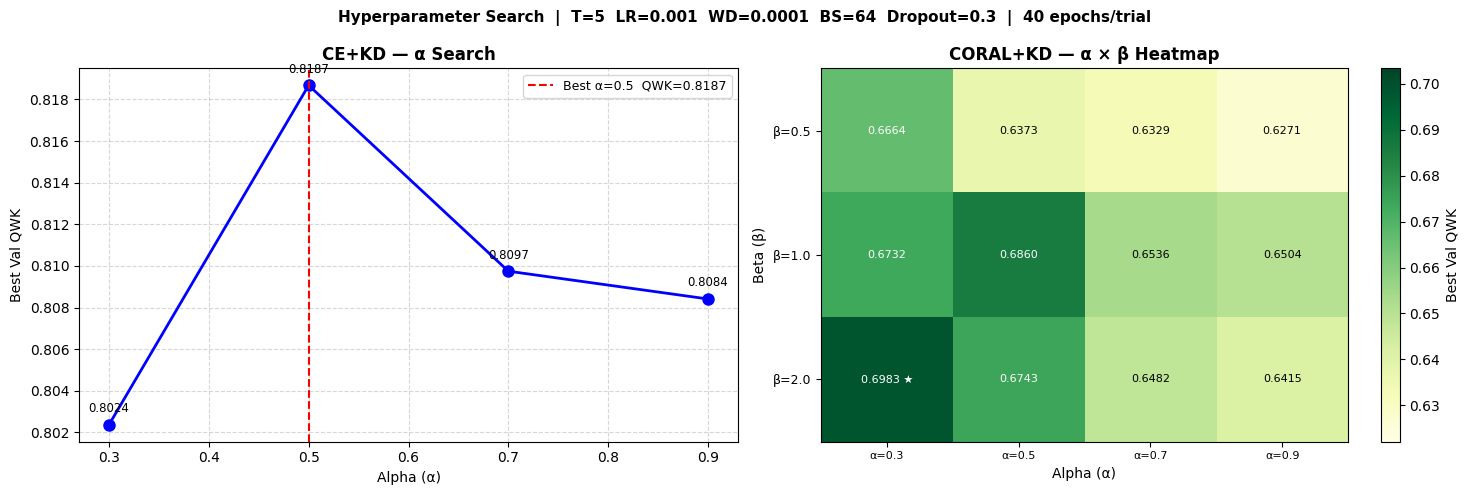

In [18]:
def plot_search_results(ce_results, coral_results, T_fixed):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(
        f"Hyperparameter Search  |  T={T_fixed}  LR={best_lr}  WD={best_wd}  "
        f"BS={best_bs}  Dropout={best_dropout}  |  {SEARCH_EPOCHS} epochs/trial",
        fontsize=11, fontweight='bold')

    ax  = axes[0]
    df  = pd.DataFrame(ce_results).sort_values('alpha')
    ax.plot(df['alpha'], df['qwk'], 'bo-', lw=2, ms=8)
    best_row = df.loc[df['qwk'].idxmax()]
    ax.axvline(best_row['alpha'], color='red', ls='--',
               label=f"Best α={best_row['alpha']}  QWK={best_row['qwk']:.4f}")
    for _, row in df.iterrows():
        ax.annotate(f"{row['qwk']:.4f}", (row['alpha'], row['qwk']),
                    textcoords="offset points", xytext=(0, 9),
                    ha='center', fontsize=8.5)
    ax.set_title("CE+KD — α Search", fontweight='bold')
    ax.set_xlabel("Alpha (α)"); ax.set_ylabel("Best Val QWK")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax  = axes[1]
    df2 = pd.DataFrame(coral_results)
    pivot = df2.pivot_table(index='beta', columns='alpha', values='qwk')
    im    = ax.imshow(pivot.values, cmap='YlGn', aspect='auto',
                      vmin=pivot.values.min() - 0.005,
                      vmax=pivot.values.max() + 0.005)
    plt.colorbar(im, ax=ax, label='Best Val QWK')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"α={v}" for v in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"β={v}" for v in pivot.index], fontsize=9)
    ax.set_title("CORAL+KD — α × β Heatmap", fontweight='bold')
    ax.set_xlabel("Alpha (α)"); ax.set_ylabel("Beta (β)")
    best_coral_row = df2.loc[df2['qwk'].idxmax()]
    for i, b in enumerate(pivot.index):
        for j, a in enumerate(pivot.columns):
            val  = pivot.loc[b, a]
            star = " ★" if (b == best_coral_row['beta'] and
                            a == best_coral_row['alpha']) else ""
            ax.text(j, i, f"{val:.4f}{star}", ha='center', va='center',
                    fontsize=8,
                    color='white' if val > pivot.values.mean() else 'black')

    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/hparam_search_results.png', dpi=130, bbox_inches='tight')
    plt.show()

plot_search_results(ce_results, coral_results, T_fixed)

In [19]:
def is_final_run_done(prefix, seed):
    resume_path = f'{CKPT_DIR}/{prefix}_seed{seed}_resume.pth'
    if not os.path.exists(resume_path): return False
    ckpt = torch.load(resume_path, map_location='cpu', weights_only=False)
    return ckpt['epoch'] >= NUM_EPOCHS - 1

In [20]:
def train_final_ce_kd(seed, alpha, temperature):
    prefix      = 'final_ce'
    best_path   = f'{CKPT_DIR}/{prefix}_seed{seed}_best.pth'
    resume_path = f'{CKPT_DIR}/{prefix}_seed{seed}_resume.pth'

    if is_final_run_done(prefix, seed):
        print(f"  [checkpoint] CE+KD seed {seed} already complete")
        student = make_mobilenet_ce(best_dropout).to(device)
        student.load_state_dict(torch.load(best_path, map_location=device,
                                            weights_only=False)['model_state_dict'])
        student.eval()
        ckpt = torch.load(resume_path, map_location='cpu', weights_only=False)
        return {'qwk': ckpt['best_qwk'], 'history': ckpt['history'],
                'preds': ckpt['best_preds'], 'labels': ckpt['best_labels'],
                'seed': seed, 'model': student}

    set_seed(seed)
    student = make_mobilenet_ce(best_dropout).to(device)
    t_ref   = shared_teacher.to(device).eval()
    for p in t_ref.parameters(): p.requires_grad_(False)
    opt     = optim.AdamW(student.parameters(), lr=best_lr, weight_decay=best_wd)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler  = torch.amp.GradScaler('cuda')
    history = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
               'val_mae': [], 'val_rmse': []}
    best_qwk = -1.0; best_preds, best_labels = [], []; start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                s_logits = student(imgs); t_logits = t_ref(imgs).detach()
                s_log    = F.log_softmax(s_logits / temperature, dim=1)
                p_t      = F.softmax(t_logits / temperature, dim=1)
                kl       = ((p_t * (p_t.log() - s_log)).sum(dim=1) *
                            temperature**2).clamp(max=10.0)
                loss     = ((1 - alpha) * F.cross_entropy(s_logits, labels) +
                            alpha * kl.mean())
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()
        sched.step()
        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(student(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        acc = np.mean(np.array(v_labels) == np.array(v_preds))
        _, rmse, mae = _compute_mse_rmse(v_labels, v_preds)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)
        print(f"  [CE-KD s{seed}] Epoch {epoch+1:03d} | Loss={avg_loss:.4f} | "
              f"Acc={acc*100:.2f}% | QWK={qwk:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")
        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(best_path, epoch+1, student, best_qwk)
        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(torch.load(best_path, map_location=device,
                                        weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed, 'model': student}

In [21]:
def train_final_coral_kd(seed, alpha, temperature, beta):
    prefix      = 'final_coral'
    best_path   = f'{CKPT_DIR}/{prefix}_seed{seed}_best.pth'
    resume_path = f'{CKPT_DIR}/{prefix}_seed{seed}_resume.pth'

    if is_final_run_done(prefix, seed):
        print(f"  [checkpoint] CORAL+KD seed {seed} already complete")
        student = make_mobilenet_coral(best_dropout).to(device)
        student.load_state_dict(torch.load(best_path, map_location=device,
                                            weights_only=False)['model_state_dict'])
        student.eval()
        ckpt = torch.load(resume_path, map_location='cpu', weights_only=False)
        return {'qwk': ckpt['best_qwk'], 'history': ckpt['history'],
                'preds': ckpt['best_preds'], 'labels': ckpt['best_labels'],
                'seed': seed, 'model': student}

    set_seed(seed)
    student = make_mobilenet_coral(best_dropout).to(device)
    t_ref   = shared_teacher.to(device).eval()
    for p in t_ref.parameters(): p.requires_grad_(False)
    opt     = optim.AdamW(student.parameters(), lr=best_lr, weight_decay=best_wd)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler  = torch.amp.GradScaler('cuda')
    history = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
               'val_mae': [], 'val_rmse': []}
    best_qwk = -1.0; best_preds, best_labels = [], []; start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                feat     = student.classifier(student.features(imgs).mean([2, 3]))
                s_logits = student.coral_head(feat)
                t_logits = t_ref(imgs).detach()
                loss     = coral_kd_loss(s_logits, t_logits, labels,
                                         alpha=alpha, temperature=temperature, beta=beta)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()
        sched.step()
        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                feat    = student.classifier(student.features(imgs.to(device)).mean([2, 3]))
                logits  = student.coral_head(feat)
                v_preds.extend(coral_predict(logits).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        acc = np.mean(np.array(v_labels) == np.array(v_preds))
        _, rmse, mae = _compute_mse_rmse(v_labels, v_preds)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)
        print(f"  [CORAL-KD s{seed}] Epoch {epoch+1:03d} | Loss={avg_loss:.4f} | "
              f"Acc={acc*100:.2f}% | QWK={qwk:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")
        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(best_path, epoch+1, student, best_qwk)
        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(torch.load(best_path, map_location=device,
                                        weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed, 'model': student}

In [22]:
# ── CHANGE 5: evaluate on both test and auto_test ────────────────────────────
def evaluate_on_test_ce(model, loader):
    model.eval(); t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            t_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds = np.array(t_preds); t_labels = np.array(t_labels)
    qwk = float(cohen_kappa_score(t_labels, t_preds, weights='quadratic'))
    acc = float(np.mean(t_labels == t_preds))
    mse, rmse, mae = _compute_mse_rmse(t_labels, t_preds)
    return {'qwk': qwk, 'acc': acc, 'mse': mse, 'rmse': rmse, 'mae': mae,
            'preds': t_preds.tolist(), 'labels': t_labels.tolist()}

def evaluate_on_test_coral(model, loader):
    model.eval(); t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            feat   = model.classifier(model.features(imgs.to(device)).mean([2, 3]))
            logits = model.coral_head(feat)
            t_preds.extend(coral_predict(logits).cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds = np.array(t_preds); t_labels = np.array(t_labels)
    qwk = float(cohen_kappa_score(t_labels, t_preds, weights='quadratic'))
    acc = float(np.mean(t_labels == t_preds))
    mse, rmse, mae = _compute_mse_rmse(t_labels, t_preds)
    return {'qwk': qwk, 'acc': acc, 'mse': mse, 'rmse': rmse, 'mae': mae,
            'preds': t_preds.tolist(), 'labels': t_labels.tolist()}

In [23]:
print("\n" + "="*65)
print("  FINAL RUNS — seeds [33, 81, 5]")
print(f"  CE+KD:    T={T_fixed}  α={best_ce['alpha']}")
print(f"  CORAL+KD: T={T_fixed}  α={best_coral['alpha']}  β={best_coral['beta']}")
print("="*65)

results_ce_final, results_coral_final   = [], []
students_ce_final, students_coral_final = [], []

for seed in [33, 81, 5]:
    print(f"\n── Seed {seed} — CE+KD ──")
    res = train_final_ce_kd(seed, alpha=best_ce['alpha'], temperature=T_fixed)
    results_ce_final.append(res); students_ce_final.append(res['model'])
    cleanup_memory()

    print(f"\n── Seed {seed} — CORAL+KD ──")
    res = train_final_coral_kd(seed, alpha=best_coral['alpha'],
                                temperature=T_fixed, beta=best_coral['beta'])
    results_coral_final.append(res); students_coral_final.append(res['model'])
    cleanup_memory()


  FINAL RUNS — seeds [33, 81, 5]
  CE+KD:    T=5  α=0.5
  CORAL+KD: T=5  α=0.3  β=2.0

── Seed 33 — CE+KD ──
  [checkpoint] CE+KD seed 33 already complete
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 213MB/s]



── Seed 33 — CORAL+KD ──
  [checkpoint] CORAL+KD seed 33 already complete

── Seed 81 — CE+KD ──
  [checkpoint] CE+KD seed 81 already complete

── Seed 81 — CORAL+KD ──
  [checkpoint] CORAL+KD seed 81 already complete

── Seed 5 — CE+KD ──
  [checkpoint] CE+KD seed 5 already complete

── Seed 5 — CORAL+KD ──
  [checkpoint] CORAL+KD seed 5 already complete


In [24]:
test_ce_final,      test_coral_final      = [], []
auto_test_ce_final, auto_test_coral_final = [], []

for seed, m_ce, m_coral in zip([33, 81, 5], students_ce_final, students_coral_final):
    # standard test
    r = evaluate_on_test_ce(m_ce, test_loader);
    r['seed'] = seed; test_ce_final.append(r)
    r = evaluate_on_test_coral(m_coral, test_loader);
    r['seed'] = seed; test_coral_final.append(r)
    # auto_test
    r = evaluate_on_test_ce(m_ce, auto_test_loader);
    r['seed'] = seed; auto_test_ce_final.append(r)
    r = evaluate_on_test_coral(m_coral, auto_test_loader);
    r['seed'] = seed; auto_test_coral_final.append(r)

def _print_results_table(label, results):
    qwks = [r['qwk'] for r in results]; accs = [r['acc']*100 for r in results]
    print(f"\n  {label}")
    print(f"  {'Seed':<6}  {'QWK':>8}  {'Accuracy':>10}  {'RMSE':>8}  {'MAE':>8}")
    print("  " + "-"*46)
    for r in results:
        print(f"  {r['seed']:<6}  {r['qwk']:>8.4f}  {r['acc']*100:>9.2f}%  "
              f"{r['rmse']:>8.4f}  {r['mae']:>8.4f}")
    print("  " + "-"*46)
    print(f"  {'Mean':<6}  {np.mean(qwks):>8.4f}  {np.mean(accs):>9.2f}%  "
          f"{np.mean([r['rmse'] for r in results]):>8.4f}  "
          f"{np.mean([r['mae'] for r in results]):>8.4f}")
    print(f"  {'Std':<6}  {np.std(qwks):>8.4f}  {np.std(accs):>9.2f}%")

print("\n" + "="*65)
print("  FINAL TEST RESULTS  (test/)")
print("="*65)
for label, results in [("CE+KD", test_ce_final), ("CORAL+KD", test_coral_final)]:
    _print_results_table(label, results)

print("\n" + "="*65)
print("  FINAL AUTO-TEST RESULTS  (auto_test/)")
print("="*65)
for label, results in [("CE+KD", auto_test_ce_final), ("CORAL+KD", auto_test_coral_final)]:
    _print_results_table(label, results)


  FINAL TEST RESULTS  (test/)

  CE+KD
  Seed         QWK    Accuracy      RMSE       MAE
  ----------------------------------------------
  33        0.8174      62.98%    0.7114    0.4143
  81        0.8158      64.43%    0.7236    0.4112
  5         0.8216      65.88%    0.7109    0.3955
  ----------------------------------------------
  Mean      0.8183      64.43%    0.7153    0.4070
  Std       0.0024       1.18%

  CORAL+KD
  Seed         QWK    Accuracy      RMSE       MAE
  ----------------------------------------------
  33        0.7566      50.66%    0.9558    0.6298
  81        0.7304      52.29%    0.9826    0.6359
  5         0.7324      47.58%    1.0300    0.6975
  ----------------------------------------------
  Mean      0.7398      50.18%    0.9895    0.6544
  Std       0.0119       1.95%

  FINAL AUTO-TEST RESULTS  (auto_test/)

  CE+KD
  Seed         QWK    Accuracy      RMSE       MAE
  ----------------------------------------------
  33        0.8127      61.99%

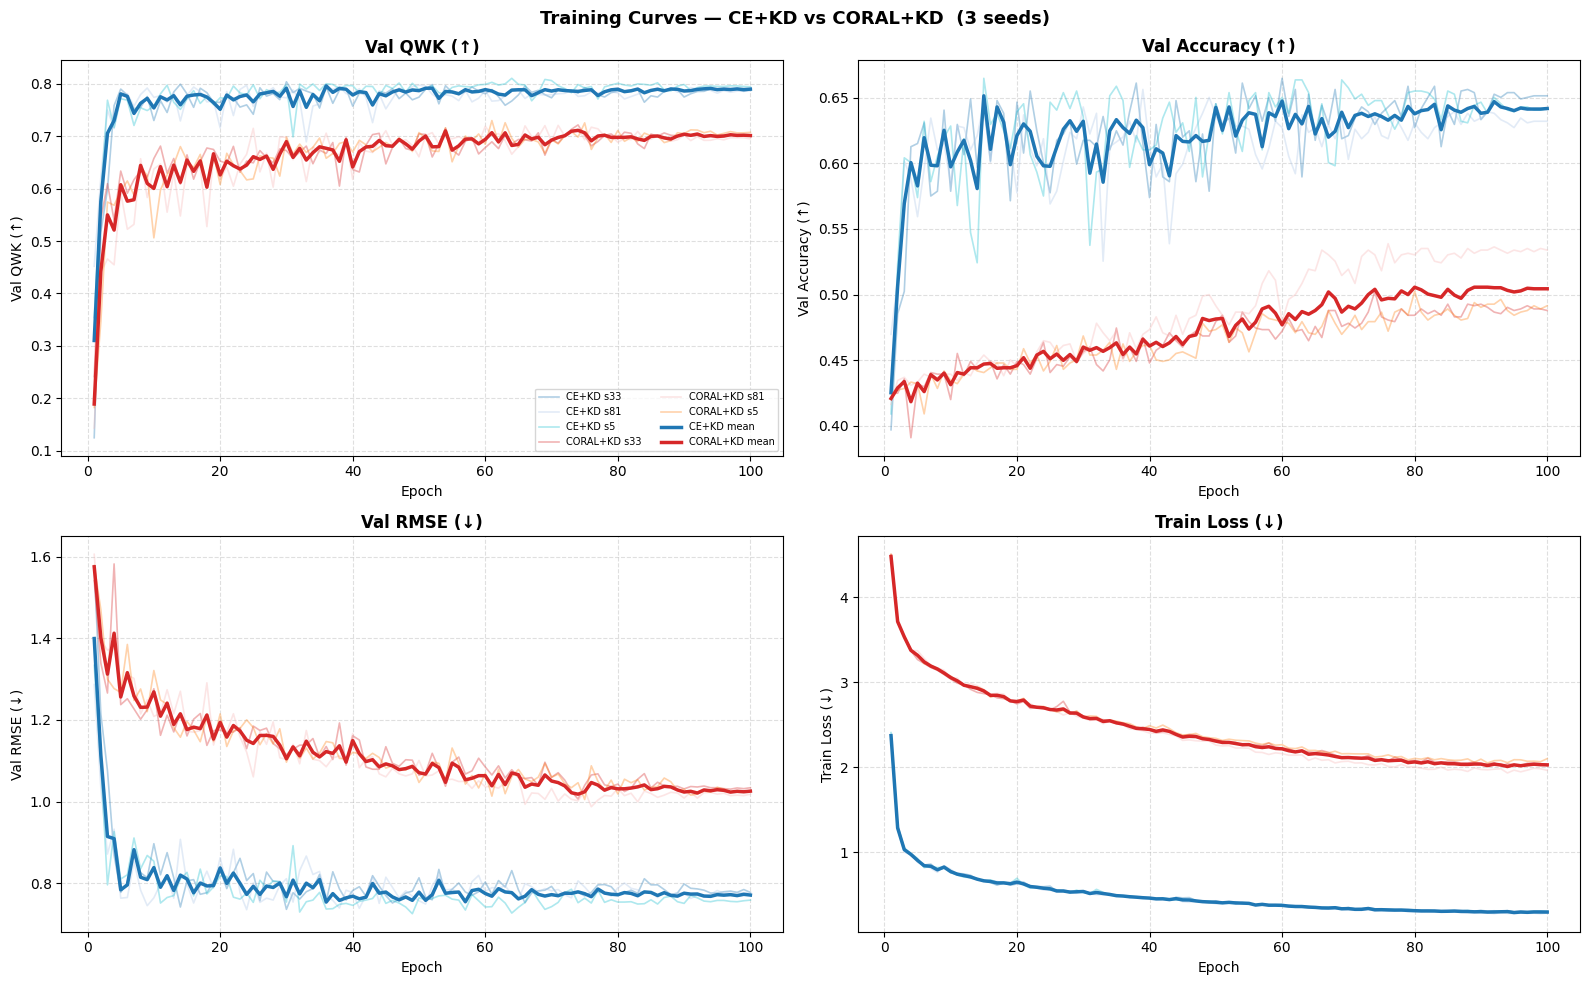

  [saved] /kaggle/working/training_curves.png


In [25]:
def plot_training_curves(results_ce, results_coral, save_path):
    metrics   = ['val_qwk', 'val_acc', 'val_rmse', 'train_loss']
    ylabels   = ['Val QWK (↑)', 'Val Accuracy (↑)', 'Val RMSE (↓)', 'Train Loss (↓)']
    colors_ce    = ['#1f77b4', '#aec7e8', '#17becf']
    colors_coral = ['#d62728', '#f7b6b6', '#ff7f0e']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Training Curves — CE+KD vs CORAL+KD  (3 seeds)',
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for ax_idx, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
        ax = axes[ax_idx]
        ce_arrays    = [r['history'][metric] for r in results_ce]
        coral_arrays = [r['history'][metric] for r in results_coral]
        min_len_ce   = min(len(a) for a in ce_arrays)
        min_len_coral= min(len(a) for a in coral_arrays)
        ce_arrays    = [a[:min_len_ce]    for a in ce_arrays]
        coral_arrays = [a[:min_len_coral] for a in coral_arrays]
        epochs_ce    = range(1, min_len_ce + 1)
        epochs_coral = range(1, min_len_coral + 1)

        for i, (arr, res) in enumerate(zip(ce_arrays, results_ce)):
            ax.plot(epochs_ce, arr, color=colors_ce[i], alpha=0.35, lw=1.2,
                    label=f'CE+KD s{res["seed"]}')
        for i, (arr, res) in enumerate(zip(coral_arrays, results_coral)):
            ax.plot(epochs_coral, arr, color=colors_coral[i], alpha=0.35, lw=1.2,
                    label=f'CORAL+KD s{res["seed"]}')

        ce_mean    = np.mean(np.array(ce_arrays),    axis=0)
        coral_mean = np.mean(np.array(coral_arrays), axis=0)
        ax.plot(epochs_ce,    ce_mean,    color='#1f77b4', lw=2.5, label='CE+KD mean')
        ax.plot(epochs_coral, coral_mean, color='#d62728', lw=2.5, label='CORAL+KD mean')

        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(ylabel, fontweight='bold')
        ax.grid(True, ls='--', alpha=0.4)
        if ax_idx == 0:
            ax.legend(fontsize=7, ncol=2, loc='lower right')

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  [saved] {save_path}")

plot_training_curves(results_ce_final, results_coral_final,
                     f'{CKPT_DIR}/training_curves.png')

In [26]:
def print_per_class_report(test_ce, test_coral):
    for label, results in [("CE+KD", test_ce), ("CORAL+KD", test_coral)]:
        best = max(results, key=lambda r: r['qwk'])
        print(f"\n{'='*65}")
        print(f"  {label}  — seed {best['seed']}  (test QWK={best['qwk']:.4f})")
        print(f"{'='*65}")
        print(classification_report(
            best['labels'], best['preds'],
            target_names=DISPLAY_NAMES, digits=4))

print("\n── Per-class report (test/) ──────────────────────────────────────────")
print_per_class_report(test_ce_final, test_coral_final)

print("\n── Per-class report (auto_test/) ────────────────────────────────────")
print_per_class_report(auto_test_ce_final, auto_test_coral_final)


── Per-class report (test/) ──────────────────────────────────────────

  CE+KD  — seed 5  (test QWK=0.8216)
                    precision    recall  f1-score   support

 Grade 0 (Healthy)     0.7570    0.7653    0.7611       639
Grade 1 (Doubtful)     0.3462    0.4257    0.3818       296
 Grade 2 (Minimal)     0.6981    0.5638    0.6238       447
Grade 3 (Moderate)     0.7826    0.8072    0.7947       223
  Grade 4 (Severe)     0.8000    0.8627    0.8302        51

          accuracy                         0.6588      1656
         macro avg     0.6768    0.6849    0.6783      1656
      weighted avg     0.6724    0.6588    0.6629      1656


  CORAL+KD  — seed 33  (test QWK=0.7566)
                    precision    recall  f1-score   support

 Grade 0 (Healthy)     0.5935    0.9781    0.7388       639
Grade 1 (Doubtful)     0.2550    0.1284    0.1708       296
 Grade 2 (Minimal)     0.8468    0.2103    0.3369       447
Grade 3 (Moderate)     0.3263    0.1390    0.1950       223
  Gr

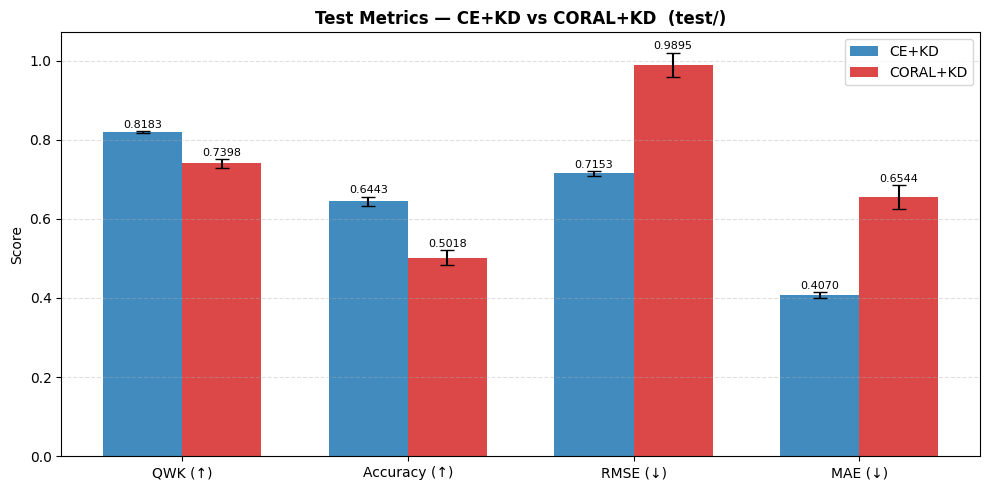

  [saved] /kaggle/working/metric_comparison_test.png


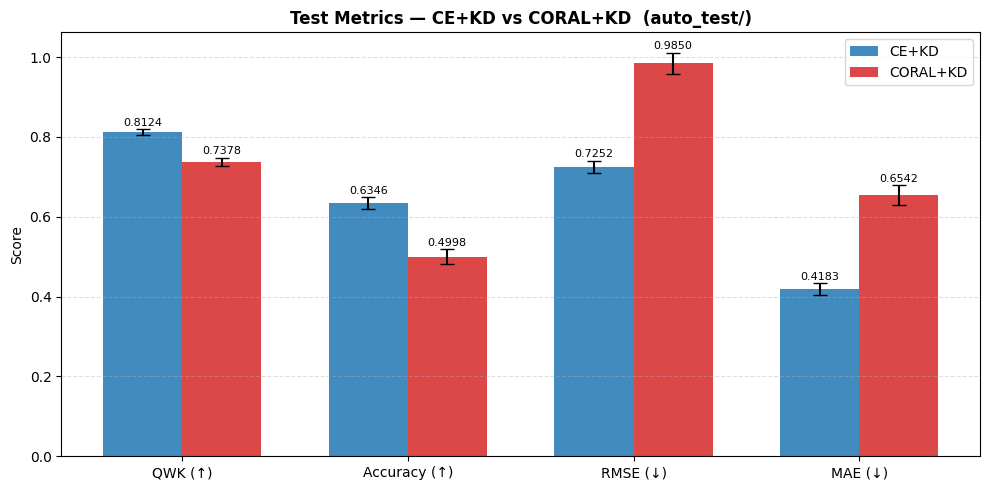

  [saved] /kaggle/working/metric_comparison_auto_test.png


In [27]:
def plot_metric_comparison(test_ce, test_coral, title_suffix, save_path):
    metrics   = ['qwk',  'acc',  'rmse', 'mae']
    labels_m  = ['QWK (↑)', 'Accuracy (↑)', 'RMSE (↓)', 'MAE (↓)']
    ce_means  = [np.mean([r[m] for r in test_ce])    for m in metrics]
    ce_stds   = [np.std( [r[m] for r in test_ce])    for m in metrics]
    co_means  = [np.mean([r[m] for r in test_coral]) for m in metrics]
    co_stds   = [np.std( [r[m] for r in test_coral]) for m in metrics]

    x = np.arange(len(metrics)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    bars_ce    = ax.bar(x - width/2, ce_means, width, yerr=ce_stds,
                        capsize=5, color='#1f77b4', label='CE+KD',    alpha=0.85)
    bars_coral = ax.bar(x + width/2, co_means, width, yerr=co_stds,
                        capsize=5, color='#d62728', label='CORAL+KD', alpha=0.85)
    for bar, mean, std in zip(list(bars_ce) + list(bars_coral),
                               ce_means + co_means, ce_stds + co_stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + 0.003,
                f"{mean:.4f}", ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels_m, fontsize=10)
    ax.set_ylabel('Score'); ax.set_ylim(bottom=0)
    ax.set_title(f'Test Metrics — CE+KD vs CORAL+KD  ({title_suffix})',
                 fontweight='bold')
    ax.legend(); ax.grid(True, axis='y', ls='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  [saved] {save_path}")

plot_metric_comparison(test_ce_final,      test_coral_final,
                       "test/",      f'{CKPT_DIR}/metric_comparison_test.png')
plot_metric_comparison(auto_test_ce_final, auto_test_coral_final,
                       "auto_test/", f'{CKPT_DIR}/metric_comparison_auto_test.png')

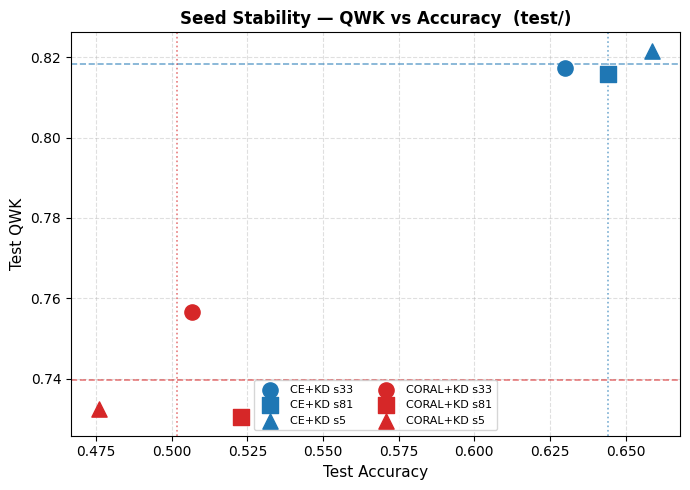

  [saved] /kaggle/working/seed_stability_test.png


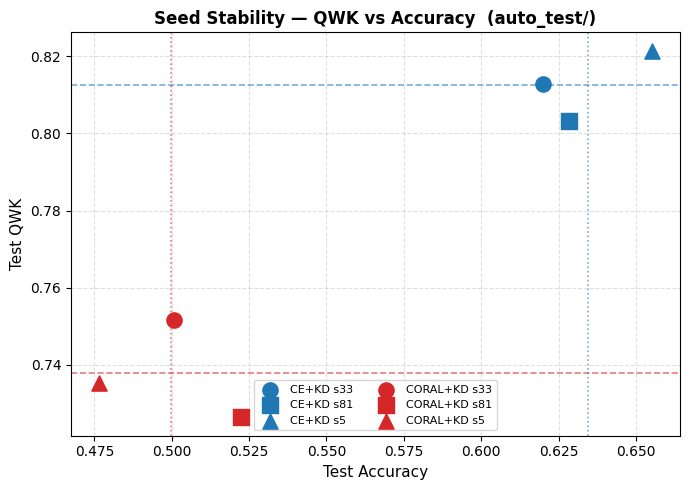

  [saved] /kaggle/working/seed_stability_auto_test.png


In [28]:
def plot_seed_stability(test_ce, test_coral, title_tag, save_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    markers = ['o', 's', '^']
    for r, mk in zip(test_ce,    markers): ax.scatter(r['acc'], r['qwk'], color='#1f77b4', marker=mk, s=120, zorder=5, label=f"CE+KD s{r['seed']}")
    for r, mk in zip(test_coral, markers): ax.scatter(r['acc'], r['qwk'], color='#d62728', marker=mk, s=120, zorder=5, label=f"CORAL+KD s{r['seed']}")
    ax.axhline(np.mean([r['qwk'] for r in test_ce]),    color='#1f77b4', ls='--', lw=1.2, alpha=0.6)
    ax.axhline(np.mean([r['qwk'] for r in test_coral]), color='#d62728', ls='--', lw=1.2, alpha=0.6)
    ax.axvline(np.mean([r['acc'] for r in test_ce]),    color='#1f77b4', ls=':',  lw=1.2, alpha=0.6)
    ax.axvline(np.mean([r['acc'] for r in test_coral]), color='#d62728', ls=':',  lw=1.2, alpha=0.6)
    ax.set_xlabel('Test Accuracy', fontsize=11); ax.set_ylabel('Test QWK', fontsize=11)
    ax.set_title(f'Seed Stability — QWK vs Accuracy  ({title_tag})', fontweight='bold')
    ax.legend(fontsize=8, ncol=2); ax.grid(True, ls='--', alpha=0.4)
    plt.tight_layout(); plt.savefig(save_path, dpi=130, bbox_inches='tight'); plt.show()
    print(f"  [saved] {save_path}")

plot_seed_stability(test_ce_final,      test_coral_final,
                    "test/",      f'{CKPT_DIR}/seed_stability_test.png')
plot_seed_stability(auto_test_ce_final, auto_test_coral_final,
                    "auto_test/", f'{CKPT_DIR}/seed_stability_auto_test.png')

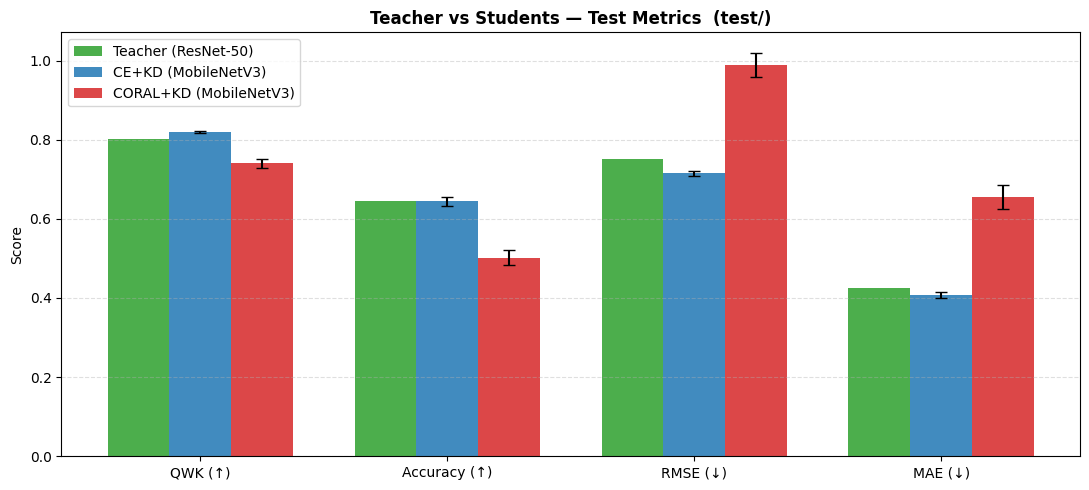

  [saved] /kaggle/working/teacher_vs_students_test.png


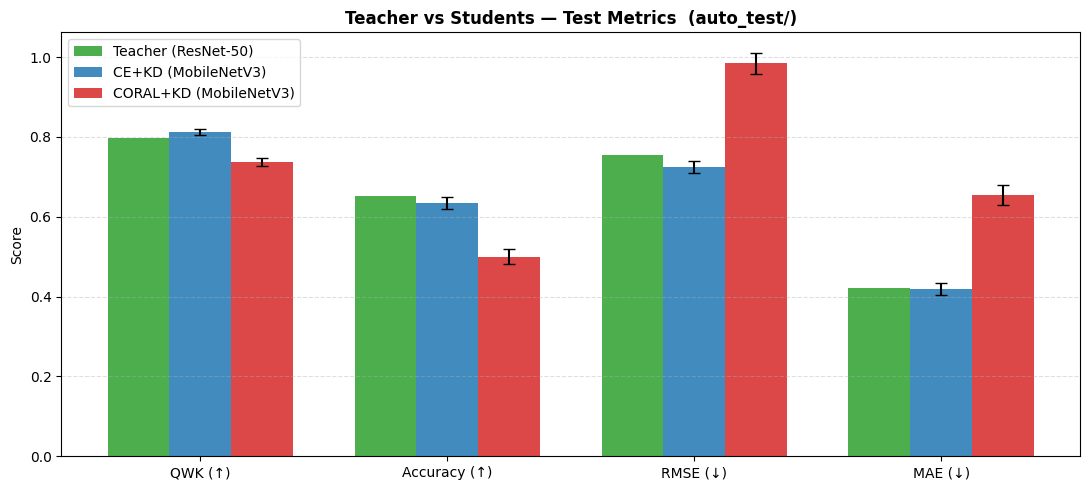

  [saved] /kaggle/working/teacher_vs_students_auto_test.png


In [29]:
def evaluate_teacher_on_test(model, loader):
    model.eval(); t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            t_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds  = np.array(t_preds); t_labels = np.array(t_labels)
    qwk  = float(cohen_kappa_score(t_labels, t_preds, weights='quadratic'))
    acc  = float(np.mean(t_labels == t_preds))
    _, rmse, mae = _compute_mse_rmse(t_labels, t_preds)
    return {'qwk': qwk, 'acc': acc, 'rmse': rmse, 'mae': mae}

teacher_test      = evaluate_teacher_on_test(shared_teacher, test_loader)
teacher_auto_test = evaluate_teacher_on_test(shared_teacher, auto_test_loader)

def plot_teacher_vs_students(teacher_metrics, test_ce, test_coral, title_suffix, save_path):
    metrics  = ['qwk', 'acc', 'rmse', 'mae']
    labels_m = ['QWK (↑)', 'Accuracy (↑)', 'RMSE (↓)', 'MAE (↓)']
    t_vals   = [teacher_metrics[m] for m in metrics]
    ce_mu    = [np.mean([r[m] for r in test_ce])    for m in metrics]
    co_mu    = [np.mean([r[m] for r in test_coral]) for m in metrics]
    ce_sd    = [np.std( [r[m] for r in test_ce])    for m in metrics]
    co_sd    = [np.std( [r[m] for r in test_coral]) for m in metrics]

    x = np.arange(len(metrics)); width = 0.25
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - width,  t_vals, width,  color='#2ca02c', label='Teacher (ResNet-50)', alpha=0.85)
    ax.bar(x,          ce_mu,  width,  yerr=ce_sd, capsize=4, color='#1f77b4', label='CE+KD (MobileNetV3)',    alpha=0.85)
    ax.bar(x + width,  co_mu,  width,  yerr=co_sd, capsize=4, color='#d62728', label='CORAL+KD (MobileNetV3)', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels_m, fontsize=10)
    ax.set_ylabel('Score'); ax.set_ylim(bottom=0)
    ax.set_title(f'Teacher vs Students — Test Metrics  ({title_suffix})', fontweight='bold')
    ax.legend(); ax.grid(True, axis='y', ls='--', alpha=0.4)
    plt.tight_layout(); plt.savefig(save_path, dpi=130, bbox_inches='tight'); plt.show()
    print(f"  [saved] {save_path}")

plot_teacher_vs_students(teacher_test,      test_ce_final,      test_coral_final,
                         "test/",      f'{CKPT_DIR}/teacher_vs_students_test.png')
plot_teacher_vs_students(teacher_auto_test, auto_test_ce_final, auto_test_coral_final,
                         "auto_test/", f'{CKPT_DIR}/teacher_vs_students_auto_test.png')

In [30]:
print("\n" + "="*65)
print("  EXPERIMENT SUMMARY — Knee OA KL Grading")
print("="*65)

print(f"\n  ── Hyperparameters ──────────────────────────────────────────")
print(f"  LR={best_lr}  WD={best_wd}  BS={best_bs}  Dropout={best_dropout}  T={T_fixed}")
print(f"  CE+KD α={best_ce['alpha']}  |  CORAL+KD α={best_coral['alpha']}  β={best_coral['beta']}")

for split_label, t_metrics, ce_res, co_res in [
    ("test/",      teacher_test,      test_ce_final,      test_coral_final),
    ("auto_test/", teacher_auto_test, auto_test_ce_final, auto_test_coral_final),
]:
    print(f"\n  ── Teacher (ResNet-50, {split_label}) ──────────────────────────────")
    print(f"  QWK={t_metrics['qwk']:.4f}  Acc={t_metrics['acc']*100:.2f}%  "
          f"RMSE={t_metrics['rmse']:.4f}  MAE={t_metrics['mae']:.4f}")

    print(f"\n  ── Student CE+KD (MobileNetV3-Small, {split_label}) ─────────────")
    for r in ce_res:
        print(f"  Seed {r['seed']}: QWK={r['qwk']:.4f}  Acc={r['acc']*100:.2f}%  "
              f"RMSE={r['rmse']:.4f}  MAE={r['mae']:.4f}")
    ce_q = [r['qwk'] for r in ce_res]
    print(f"  Mean QWK = {np.mean(ce_q):.4f} ± {np.std(ce_q):.4f}")

    print(f"\n  ── Student CORAL+KD (MobileNetV3-Small, {split_label}) ──────────")
    for r in co_res:
        print(f"  Seed {r['seed']}: QWK={r['qwk']:.4f}  Acc={r['acc']*100:.2f}%  "
              f"RMSE={r['rmse']:.4f}  MAE={r['mae']:.4f}")
    co_q = [r['qwk'] for r in co_res]
    print(f"  Mean QWK = {np.mean(co_q):.4f} ± {np.std(co_q):.4f}")

    winner = "CORAL+KD" if np.mean(co_q) >= np.mean(ce_q) else "CE+KD"
    delta  = abs(np.mean(co_q) - np.mean(ce_q))
    print(f"\n  Verdict ({split_label}): {winner}  (ΔQWK = {delta:.4f})")

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"\n  ── Saved Outputs ─────────────────────────────────────────────")
outputs = [
    'hparam_search_results.png',
    'training_curves.png',
    'metric_comparison_test.png',
    'metric_comparison_auto_test.png',
    'seed_stability_test.png',
    'seed_stability_auto_test.png',
    'teacher_vs_students_test.png',
    'teacher_vs_students_auto_test.png',
]
for f in outputs:
    print(f"  {CKPT_DIR}/{f}")


  EXPERIMENT SUMMARY — Knee OA KL Grading

  ── Hyperparameters ──────────────────────────────────────────
  LR=0.001  WD=0.0001  BS=64  Dropout=0.3  T=5
  CE+KD α=0.5  |  CORAL+KD α=0.3  β=2.0

  ── Teacher (ResNet-50, test/) ──────────────────────────────
  QWK=0.8007  Acc=64.43%  RMSE=0.7522  MAE=0.4245

  ── Student CE+KD (MobileNetV3-Small, test/) ─────────────
  Seed 33: QWK=0.8174  Acc=62.98%  RMSE=0.7114  MAE=0.4143
  Seed 81: QWK=0.8158  Acc=64.43%  RMSE=0.7236  MAE=0.4112
  Seed 5: QWK=0.8216  Acc=65.88%  RMSE=0.7109  MAE=0.3955
  Mean QWK = 0.8183 ± 0.0024

  ── Student CORAL+KD (MobileNetV3-Small, test/) ──────────
  Seed 33: QWK=0.7566  Acc=50.66%  RMSE=0.9558  MAE=0.6298
  Seed 81: QWK=0.7304  Acc=52.29%  RMSE=0.9826  MAE=0.6359
  Seed 5: QWK=0.7324  Acc=47.58%  RMSE=1.0300  MAE=0.6975
  Mean QWK = 0.7398 ± 0.0119

  Verdict (test/): CE+KD  (ΔQWK = 0.0785)

  ── Teacher (ResNet-50, auto_test/) ──────────────────────────────
  QWK=0.7979  Acc=65.20%  RMSE=0.7555  MAE=0.42